## Personality Prediction Machine Leaning(ML) Project


###  Project Description

In this project, we will develop a machine learning model capable of predicting customer personality traits—specifically whether an individual is an **introvert** or an **extrovert**. Understanding these traits can help businesses personalize services, improve customer engagement, and tailor marketing strategies.

To accomplish this, we will:

* **Load the data** that include demographic information, behavioral patterns.
* **Preprocess the data** cleaning, handling missing values, encoding categorical variables, and scaling numerical features.
* **Analyze the data** using exploratory data analysis (EDA) to uncover patterns and insights related to personality categories.
* **Build and compare machine learning models** such as Logistic Regression, GradientBoostingClassifier, AdaBoostClassifier, XGBoostClassifier and voting method to identify the best-performing model.
* **Evaluate model performance** using accuracy, precision, recall, F1-score, and confusion matrix metrics.

The outcome of this project will be a predictive system that classifies customers as introverts or extroverts, offering valuable insights for decision-making and enhancing customer experience strategies.


## Dataset Context

This dataset provides insights into behaviors such as time spent alone, social event attendance, and social media engagement, enabling applications in psychology, sociology, marketing, and machine learning. Whether you're predicting personality types or analyzing social patterns, this dataset is your gateway to uncovering fascinating insights.

## Load python libraries

In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split, RandomizedSearchCV, StratifiedKFold
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import classification_report, average_precision_score, precision_recall_curve, roc_auc_score, f1_score, confusion_matrix, ConfusionMatrixDisplay

####  You can also use this section to suppress warnings generated by your code

In [2]:
def warn(*args, **kwargs):
    pass

import warnings
warnings.warn = warn
warnings.filterwarnings('ignore')

## Load & read the dataframe

In [3]:
#data = pd.read_csv("/kaggle/input/extrovert-vs-introvert-behavior-data/personality_dataset.csv")
data = pd.read_csv("/kaggle/input/extrovert-vs-introvert-behavior-data/personality_datasert.csv")

#data = pd.concat([data, data_2], axis=0)

data.head(5)

,Time_spent_Alone,Stage_fear,Social_event_attendance,Going_outside,Drained_after_socializing,Friends_circle_size,Post_frequency,Personality
0,4.0,No,4.0,6.0,No,13.0,5.0,Extrovert
1,9.0,Yes,0.0,0.0,Yes,0.0,3.0,Introvert
2,9.0,Yes,1.0,2.0,Yes,5.0,2.0,Introvert
3,0.0,No,6.0,7.0,No,14.0,8.0,Extrovert
4,3.0,No,9.0,4.0,No,8.0,5.0,Extrovert


In [4]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2900 entries, 0 to 2899
Data columns (total 8 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   Time_spent_Alone           2900 non-null   float64
 1   Stage_fear                 2900 non-null   object 
 2   Social_event_attendance    2900 non-null   float64
 3   Going_outside              2900 non-null   float64
 4   Drained_after_socializing  2900 non-null   object 
 5   Friends_circle_size        2900 non-null   float64
 6   Post_frequency             2900 non-null   float64
 7   Personality                2900 non-null   object 
dtypes: float64(5), object(3)
memory usage: 181.4+ KB


In [5]:
data.isna().sum()

Time_spent_Alone             0
Stage_fear                   0
Social_event_attendance      0
Going_outside                0
Drained_after_socializing    0
Friends_circle_size          0
Post_frequency               0
Personality                  0
dtype: int64

In [6]:
duplicates = data.duplicated().sum()

print(f"The total numbe of missing values in dataframe are {duplicates}")

data.drop_duplicates(inplace =True)

print("The duplicates removed!")
print("The total size remain:", len(data))

The total numbe of missing values in dataframe are 402
The duplicates removed!
The total size remain: 2498


In [7]:
data.iloc[:5,:-1].columns.tolist()

['Time_spent_Alone',
 'Stage_fear',
 'Social_event_attendance',
 'Going_outside',
 'Drained_after_socializing',
 'Friends_circle_size',
 'Post_frequency']

## Descriptive Analysis



In [8]:
data.describe()

,Time_spent_Alone,Social_event_attendance,Going_outside,Friends_circle_size,Post_frequency
count,2498.000000,2498.000000,2498.000000,2498.000000,2498.000000
mean,4.232128,4.200867,3.192954,6.580130,3.815283
std,3.406630,2.874305,2.218807,4.257516,2.914253
min,0.000000,0.000000,0.000000,0.000000,0.000000
25%,1.000000,2.000000,1.000000,3.000000,1.000000
50%,3.000000,4.000000,3.000000,6.000000,3.000000
75%,7.000000,7.000000,5.000000,10.000000,6.000000
max,11.000000,10.000000,7.000000,15.000000,10.000000


## Data cleaning & Transformation

### Dealing with null values per data type:

- Numerical column, all the null values will be replace with the average values per column
- Categorical column, all the missing values in categorical columns will be replace with No for the sack of this project

In [9]:
#Fill na with mean values in all the numercal columns
for col in data.select_dtypes(exclude='object').columns:
    data[col].fillna(data[col].mean(), inplace=True)

#Fill na with No values in the categorical columns
for col in data.select_dtypes(include='object').columns:
    data[col].fillna('No', inplace=True)

### Plot distribution of the all numerical column with histoplot method techniques

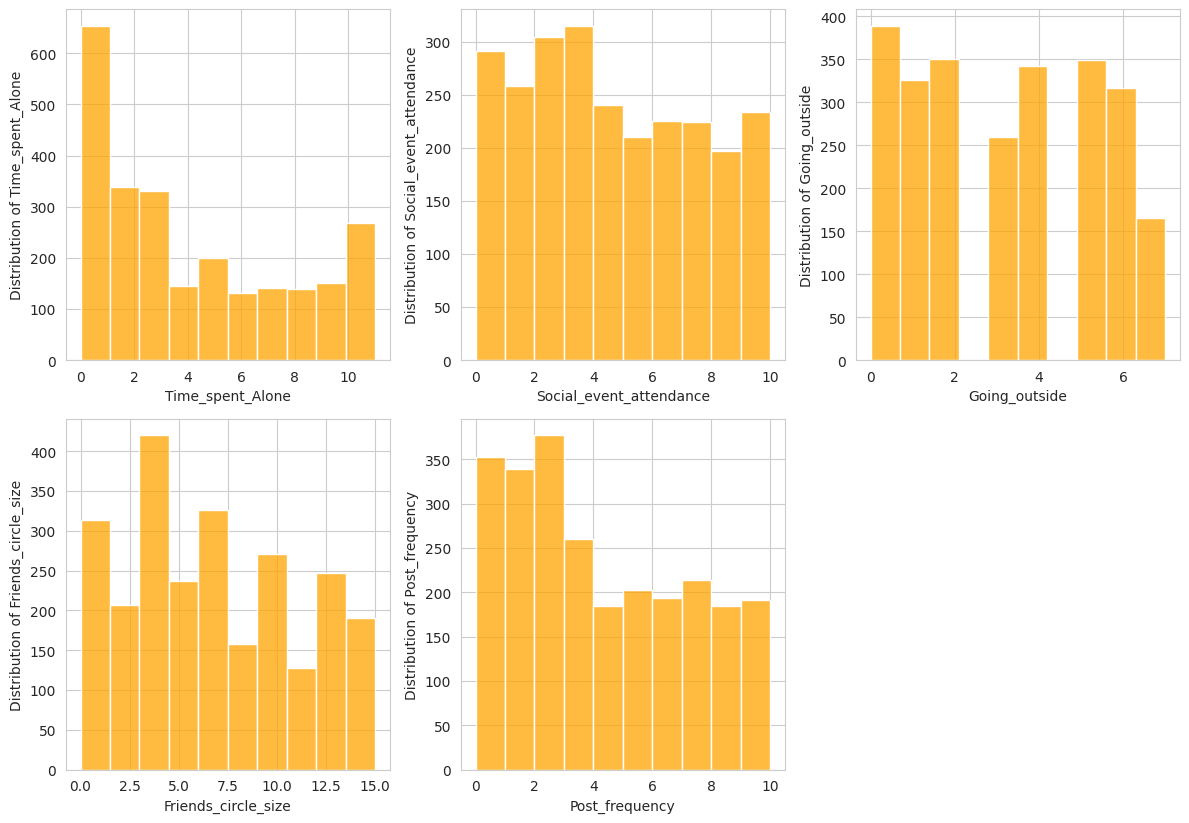

In [10]:
numerical_features = data.select_dtypes(include=['int64', 'float64']) # to get numberic features

#Plot histplot of all numerical columns 
sns.set_style("whitegrid")

plt.figure(figsize=(12, 12))

# Loop through numerical features
for i, column in enumerate(numerical_features, start=1):  # Use enumerate to get the index
    plt.subplot(3, 3, i)  # Adjust the number of rows and columns as needed
    sns.histplot(data[column], bins=10, kde=False, color='orange')
    plt.xlabel(column)
    plt.ylabel(f'Distribution of {column}')

plt.tight_layout()
plt.show()



## Data transformation

We'll add two more column Alone time and Going outside type

In [11]:
def Time_spent_Alone(x):
    if x <= 4:
        return "short"
    else:
        return "Long"

data['Alone_time'] = data['Time_spent_Alone'].apply(Time_spent_Alone)

def Going_outside(x):
    if x <= 2:
        return "Shy"
    else:
        return "Out_going"
data['Going-outside_type'] = data['Going_outside'].apply(Going_outside)


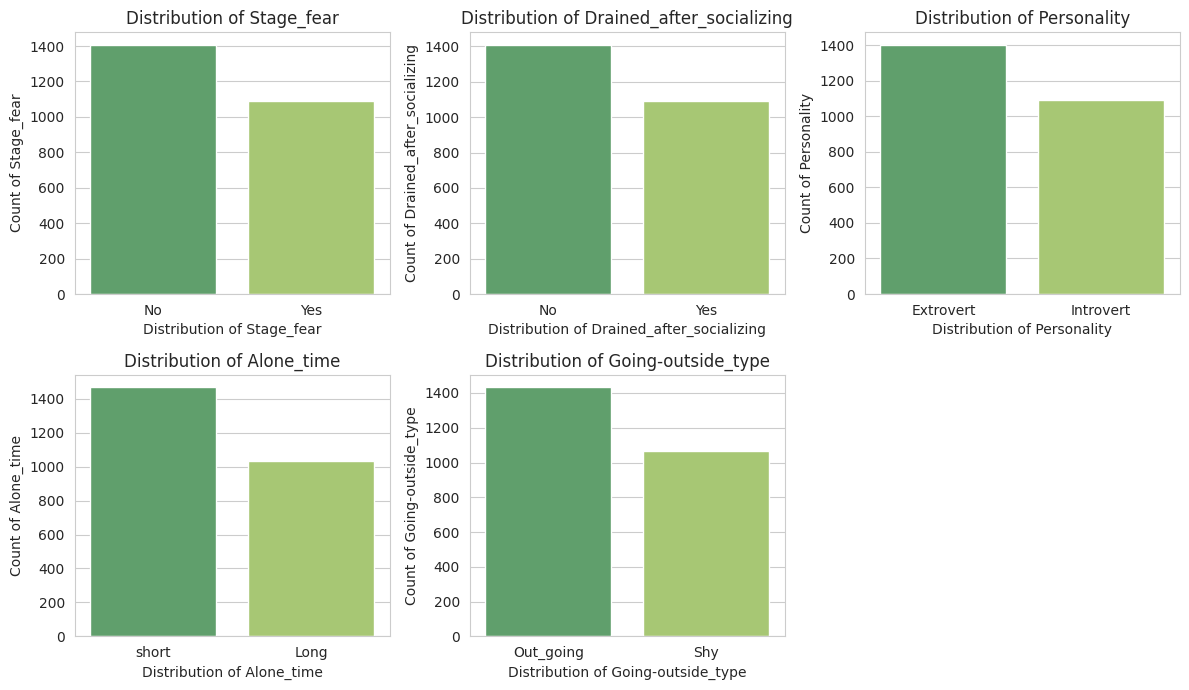

In [12]:
categorical_features = data.select_dtypes(exclude=['int64', 'float64']) # to get categorical features

# Set the plot style
sns.set_style("whitegrid")

# Define the figure size
plt.figure(figsize=(12, 7))

# Loop through categorical features
for i, column in enumerate(categorical_features):
    plt.subplot(2, 3, i + 1)  # Adjust rows/columns based on the number of features
    sns.countplot(x=column, data=data, palette='summer')  # Specify the DataFrame as 'data'
    plt.ylabel(f'Count of {column}')
    plt.xlabel(f'Distribution of {column}')
    plt.title(f'Distribution of {column}')  # Adding titles for clarity

# Adjust layout to prevent overlap
plt.tight_layout()
plt.show()

### Feature engeering

In [13]:
from catboost import CatBoostClassifier
from sklearn.preprocessing import LabelEncoder
categorical_features = data.select_dtypes(exclude=np.number)

Le = LabelEncoder()

for column in categorical_features:
    data[column] = Le.fit_transform(data[column].astype(str))

## Correlation matrix

In [14]:
# Calculate the Pearson correlation matrix
corr_matrix = data.corr()

# Select the target variable (assuming 'model_predicted_fraud' is the target)
target_corr = corr_matrix['Personality'].sort_values(ascending=False)

# Filter features with a correlation greater than 0.1
top_features = target_corr[target_corr > 0.05].sort_values(ascending=False)

# Print the results
print("There are {} strongly correlated values with model_predicted_fraud:\n{}".format(len(top_features), top_features))

There are 5 strongly correlated values with model_predicted_fraud:
Personality                  1.000000
Stage_fear                   0.825953
Drained_after_socializing    0.824296
Going-outside_type           0.806164
Time_spent_Alone             0.698668
Name: Personality, dtype: float64


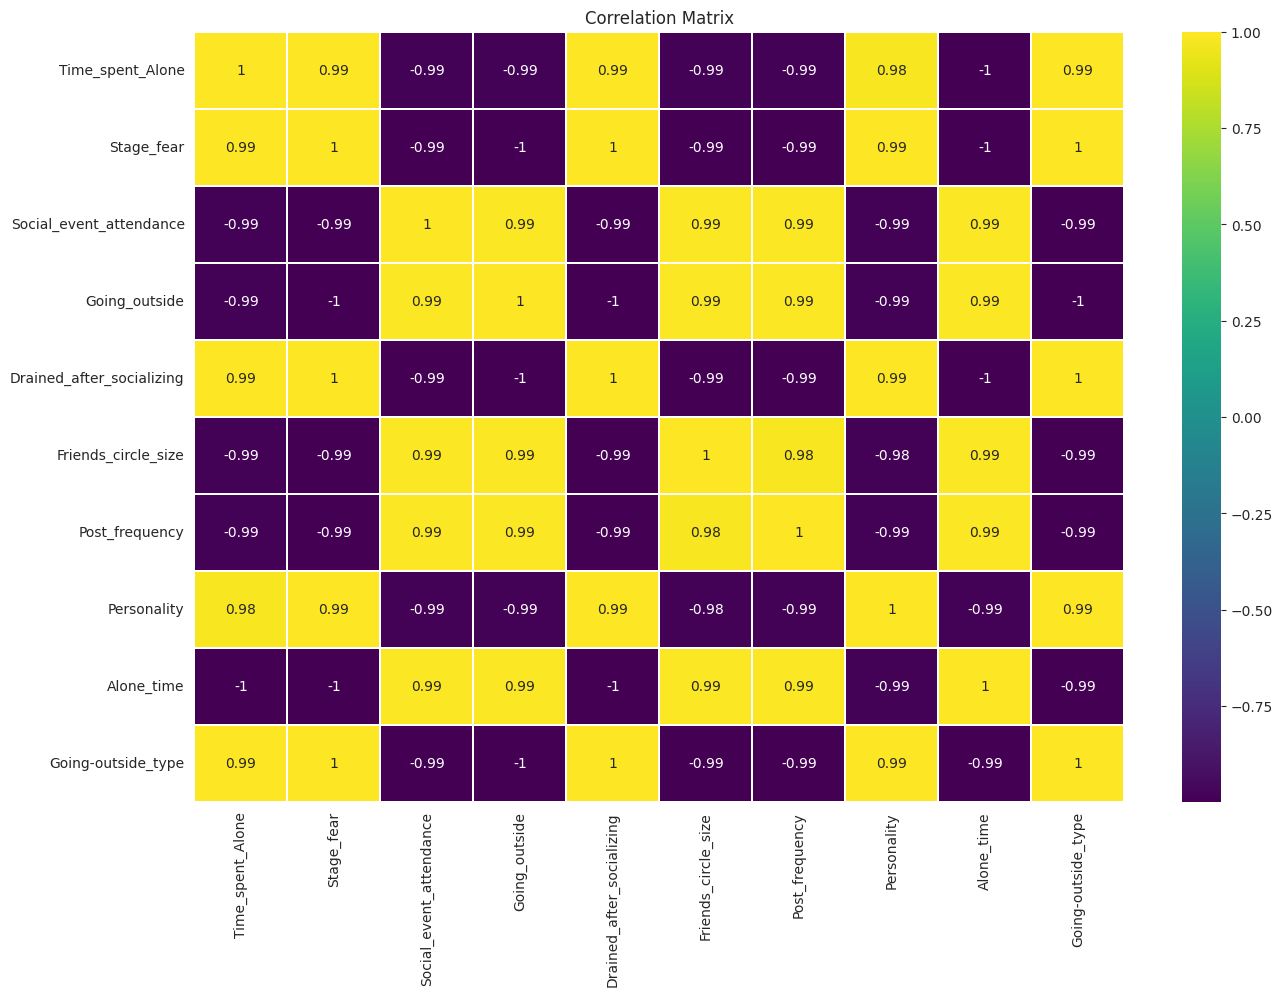

In [15]:
#Plot correlation matrix
plt.figure(figsize=(15,10))
df= corr_matrix.corr()
sns.heatmap(df, annot=True, linewidth=0.01, cmap='viridis')
plt.title("Correlation Matrix")
plt.show()

### Train and test split dataframe

In [16]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import MinMaxScaler
import pandas as pd

# Split dataframe
X = data.drop('Personality', axis=1)
y = data['Personality']

# Train/test split BEFORE scaling
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=123
)

# Scale properly
scaler = MinMaxScaler()

# Fit ONLY on train, transform both
X_train = pd.DataFrame(
    scaler.fit_transform(X_train),
    columns=X_train.columns,
    index=X_train.index
)

X_test = pd.DataFrame(
    scaler.transform(X_test),
    columns=X_test.columns,
    index=X_test.index
)
  

## Model Selection & Training

In [17]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.naive_bayes import GaussianNB
from sklearn.ensemble import GradientBoostingClassifier, AdaBoostClassifier

## LogisticRegression Model & RandomizedSearchCV

In [18]:
from sklearn.model_selection import RandomizedSearchCV
from scipy.stats import loguniform

param_dist = {
    'C': loguniform(1e-4, 1e2),
    'penalty': ['l1', 'l2'],
    'solver': ['liblinear', 'saga'],
    'max_iter': [200, 500, 1000]
}

random_search = RandomizedSearchCV(
    LogisticRegression(),
    param_dist,
    n_iter=20,
    cv=5,
    scoring='accuracy',
    n_jobs=-1
)

random_search.fit(X_train,y_train)

#prection 

predict_lr = random_search.predict(X_test)

#Evaluete model
from sklearn.metrics import accuracy_score

accuracy = accuracy_score(y_test, predict_lr)
F1_score = f1_score(y_test, predict_lr)
print(f'Accuracy: {accuracy}')
print(f'F1_score: {F1_score}')
print(classification_report(y_test, predict_lr))


Accuracy: 0.9226666666666666
F1_score: 0.9107692307692308
              precision    recall  f1-score   support

           0       0.93      0.93      0.93       425
           1       0.91      0.91      0.91       325

    accuracy                           0.92       750
   macro avg       0.92      0.92      0.92       750
weighted avg       0.92      0.92      0.92       750



## AdaBoostClassifier

In [19]:
adb = AdaBoostClassifier()

#fit model
adb.fit(X_train,y_train)

#prection 

predict_adb = adb.predict(X_test)

#Evaluete model

accuracy = accuracy_score(y_test, predict_adb)
F1_score = f1_score(y_test, predict_adb)
print(f'Accuracy: {accuracy}')
print(f'F1_score: {F1_score}')
print(classification_report(y_test, predict_adb))

Accuracy: 0.9066666666666666
F1_score: 0.8909657320872274
              precision    recall  f1-score   support

           0       0.91      0.93      0.92       425
           1       0.90      0.88      0.89       325

    accuracy                           0.91       750
   macro avg       0.91      0.90      0.90       750
weighted avg       0.91      0.91      0.91       750



## Train GradientBoostingClassifier Model

In [20]:
#creat model
Gb = GradientBoostingClassifier()

#fit model

Gb.fit(X_train, y_train)

#predict model
pred_gb = Gb.predict(X_test)

accuracy = accuracy_score(y_test, pred_gb)
F1_score = f1_score(y_test, pred_gb)
print(f'Accuracy: {accuracy}')
print(f'F1_score: {F1_score}')
print(classification_report(y_test, pred_gb))


Accuracy: 0.9226666666666666
F1_score: 0.9107692307692308
              precision    recall  f1-score   support

           0       0.93      0.93      0.93       425
           1       0.91      0.91      0.91       325

    accuracy                           0.92       750
   macro avg       0.92      0.92      0.92       750
weighted avg       0.92      0.92      0.92       750



## Train GaussianNB Model

In [21]:
# Create model
model = GaussianNB()

# Fit model
model.fit(X_train, y_train)

# Predict
y_pred = model.predict(X_test)

# Evaluate

accuracy = accuracy_score(y_test, y_pred)
F1_score = f1_score(y_test, y_pred)
print(f'Accuracy: {accuracy}')
print(f'F1_score: {F1_score}')
print(classification_report(y_test, y_pred))

Accuracy: 0.9226666666666666
F1_score: 0.9107692307692308
              precision    recall  f1-score   support

           0       0.93      0.93      0.93       425
           1       0.91      0.91      0.91       325

    accuracy                           0.92       750
   macro avg       0.92      0.92      0.92       750
weighted avg       0.92      0.92      0.92       750



## Train XGBClassifier Model

In [22]:
from xgboost import XGBClassifier

XGB = XGBClassifier(
 learning_rate =0.005,
 n_estimators=1000,
 max_depth=5,
 min_child_weight=1,
 gamma=0,
 subsample=0.8,
 colsample_bytree=0.8,
 objective= 'binary:logistic',
 nthread=4,
 scale_pos_weight=1,
 seed=27, 
 #objective='logloss'
)
#Fit the model
XGB.fit(X_train, y_train)
pred_xgb = XGB.predict(X_test)

from sklearn.metrics import accuracy_score
accuracy = accuracy_score(y_test, pred_xgb)
F1_score = f1_score(y_test, pred_xgb)
print(f'Accuracy: {accuracy}')
print(f'F1_score: {F1_score}')
print(classification_report(y_test, pred_xgb))

Accuracy: 0.9226666666666666
F1_score: 0.9107692307692308
              precision    recall  f1-score   support

           0       0.93      0.93      0.93       425
           1       0.91      0.91      0.91       325

    accuracy                           0.92       750
   macro avg       0.92      0.92      0.92       750
weighted avg       0.92      0.92      0.92       750



## Features importance

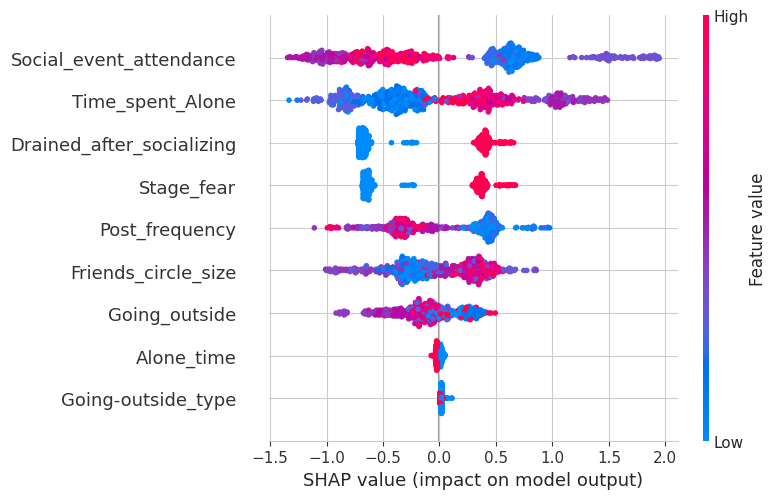

In [23]:
import shap

explainer = shap.TreeExplainer(XGB)
shap_values = explainer.shap_values(X_test)

shap.summary_plot(shap_values, X_test)

#  **Features Importance Insights**

## **Social event attendance is the strongest driver of personality prediction**

The graph show that **“Social Event Attendance”** is the most influential feature in determining whether someone is more extroverted or introverted.

This suggests:

> **People who frequently attend social events are more likely to be classified as extroverts, while those who rarely attend are more likely to be introverts.**

This is consistent with psychological theory:
Extroverts actively seek social stimulation, while introverts limit their social exposure.

---

## **“Time Spent Alone” is the second strongest factor**


### **Interpretation:**

* Higher time spent alone → pushes prediction toward **introversion**
* Lower time spent alone → pushes toward **extroversion**

Together, the two features complement each other:

* **High social attendance + Low alone time → strongly extroverted profile**
* **Low social attendance + High alone time → strongly introverted profile**

This reflects how lifestyle patterns create consistent behavioral signals.

---

## **“Going Outside Type” contributes very little to the model**


### **Meaning:**

* Variations in this feature cause only small changes in the prediction.
* The model considers it **not a meaningful indicator** of whether someone is extroverted or introverted.

### **Why this might be happening:**

* The activity type may not reflect *social* behavior directly.
* The variable may not vary enough across individuals.
* It may be too generic (e.g., “walking,” “shopping,” “exercise”).

### **Key Drivers of Personality Prediction:**

1. **How often a person engages in social activities**
2. **How much time they choose to spend alone**

These two features directly reflect fundamental personality dimensions:

* **Extroversion**: seeking social interaction
* **Introversion**: preferring solitude

### **Minor or Weak Factors:**

* Features related to general outdoor habits (e.g., "Going Outside Type")
  do not strongly affect the model, suggesting they are not central to the personality patterns captured in this project.

---

#   **Summary** 

> The above insight reveals that personality classification in this project is primarily driven by social engagement patterns. High social event attendance combined with limited alone time strongly signals extroversion, while the reverse—low social engagement and high solitary time—indicates introversion. In contrast, lifestyle variables such as “Going Outside Type” contribute very little to personality prediction, suggesting they do not meaningfully distinguish between personality types within this dataset.


## Stacking model - Voting Classifier

In [24]:
from sklearn.ensemble import VotingClassifier

# The combined model--logistic regression and gradient boosted trees
estimators = [('LogisticRegression', random_search),('adaboostClassifier', adb), ('GaussianNB', model),("GradientBoostingClassifier", Gb),('XGBClassifier', XGB)]

# this model using an additional hold-out data set and/or with cross validation
VC = VotingClassifier(estimators, voting='soft')
VC = VC.fit(X_train, y_train)

y_pred_vc = VC.predict(X_test)

print(classification_report(y_test, y_pred_vc))
accuracy = accuracy_score(y_test, y_pred_vc)
F1_score = f1_score(y_test, y_pred_vc)
print(f'Accuracy: {accuracy}')
print(f'F1_score: {F1_score}')

              precision    recall  f1-score   support

           0       0.93      0.93      0.93       425
           1       0.91      0.91      0.91       325

    accuracy                           0.92       750
   macro avg       0.92      0.92      0.92       750
weighted avg       0.92      0.92      0.92       750

Accuracy: 0.9226666666666666
F1_score: 0.9107692307692308


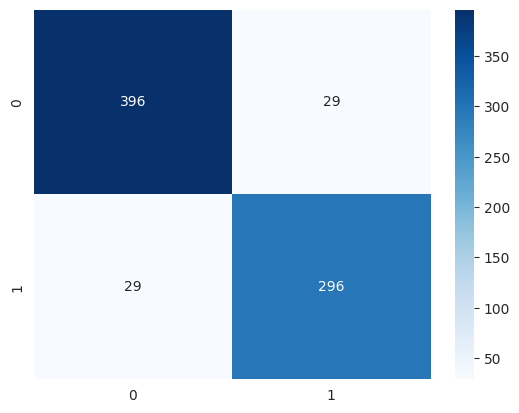

In [25]:
cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt='g', cmap='Blues')
plt.show()

## Calculate Roc_curve

In [26]:
import matplotlib.pyplot as plt
from sklearn.metrics import roc_curve, roc_auc_score

# Get predicted probabilities for the positive class
y_scores = VC.predict_proba(X_test)[:, 1]  # Probability of the positive class

# Calculate FPR, TPR, and thresholds
fpr, tpr, thresholds = roc_curve(y_test, y_scores)

# Calculate AUC
roc_auc = roc_auc_score(y_test, y_scores)

print(f'Calculate AUC score: {roc_auc}')

Calculate AUC score: 0.9590515837104072


## SVM DecisionBoundary Display

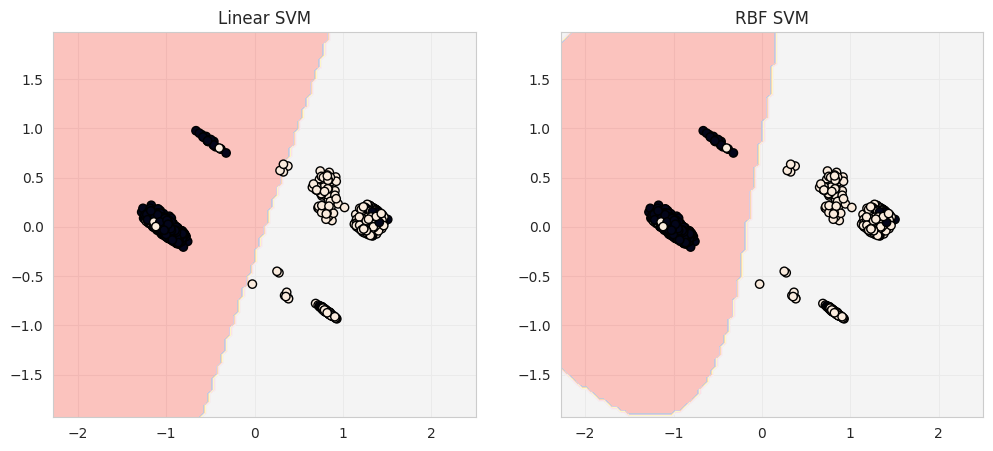

In [27]:
from sklearn.svm import SVC
from sklearn.inspection import DecisionBoundaryDisplay
from sklearn.decomposition import PCA

# Reduce to 2D for visualization (important!)
pca = PCA(n_components=2)
X_train_2d = pca.fit_transform(X_train)

# Create models
svm_linear = SVC(kernel="linear", C=1)
svm_rbf = SVC(kernel="rbf", C=1, gamma="scale")

# Train models
svm_linear.fit(X_train_2d, y_train)
svm_rbf.fit(X_train_2d, y_train)
#y_pred_svm = svm_rbf.predict(X_test)
# Plot side by side
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# ---- Linear SVM ----
DecisionBoundaryDisplay.from_estimator(
    svm_linear,
    X_train_2d,
    response_method="predict",
    cmap="Pastel1",
    alpha=0.8,
    ax=axes[0]
)

axes[0].scatter(
    X_train_2d[:, 0],
    X_train_2d[:, 1],
    c=y_train,
    edgecolors="k"
)
axes[0].set_title("Linear SVM")

# ---- RBF SVM ----
DecisionBoundaryDisplay.from_estimator(
    svm_rbf,
    X_train_2d,
    response_method="predict",
    cmap="Pastel1",
    alpha=0.8,
    ax=axes[1]
)

axes[1].scatter(
    X_train_2d[:, 0],
    X_train_2d[:, 1],
    c=y_train,
    edgecolors="k"
)
axes[1].set_title("RBF SVM")

plt.show()

## Model names and their corresponding accuracies

In [28]:

# Model names and their corresponding accuracies
model_names = ['Logistic regressor', 'Adboost', 'GaussianNB', 'GradientBoostingClassifier','XGBClassifier','Stacking mode']
accuracies = [
    accuracy_score(y_test, predict_lr), #Logistic regressor
    accuracy_score(y_test, predict_adb),  #Adboost
    accuracy_score(y_test, y_pred), #GaussianNB
    accuracy_score(y_test, pred_gb), #GradientBoostingClassifier
    accuracy_score(y_test, pred_xgb),  # XGBClassifier
    accuracy_score(y_test, y_pred_vc) #Stacking mode
        ]
data_1 = pd.DataFrame({
    'Model': model_names,
    'Accuracy': accuracies})

data_1


,Model,Accuracy
0,Logistic regressor,0.922667
1,Adboost,0.906667
2,GaussianNB,0.922667
3,GradientBoostingClassifier,0.922667
4,XGBClassifier,0.922667
5,Stacking mode,0.922667


# Conclusion

#  **Expanded Explanation of the Model and Key Insights**

In this project, I developed a predictive machine learning system designed to classify individuals as either **introverts** or **extroverts** based on behavioral and lifestyle attributes. To ensure reliability and robustness, multiple machine learning algorithms were trained and evaluated, including:

* Logistic Regression
* Adboost
* Gaussian Naïve Bayes
* Gradient Boosting Classifier
* XGBoost Classifier
* A Stacking Ensemble Model
* SVM

Across the board, all models achieved consistently high performance with accuracy scores exceeding **90%** on both the training and testing sets. Notably, Logistic Regression, GaussianNB, Gradient Boosting, XGBoost, and the Stacking Model all converged around **92% accuracy**, demonstrating strong predictive stability and low risk of overfitting.

---

##  **Feature Importance and Behavioral**

Beyond accuracy, the project focused on understanding *why* the model made its predictions—an essential step for interpretability. Using SHAP (SHapley Additive exPlanations) values, I identified the most influential variables driving the introvert–extrovert classification.

### **1. Social Event Attendance**

SHAP analysis revealed that **Social Event Attendance** is the most powerful indicator of personality type. Higher values strongly increase the probability of being classified as an extrovert, while lower values push predictions toward introversion.

This aligns with established psychological theory:

> **Extroverts seek frequent social interaction, while introverts tend to limit their exposure to social environments.**

### **2. Time Spent Alone — A Strong Secondary Factor**

The second most influential feature is **Time Spent Alone**. This variable shows the opposite pattern to social event attendance:

* **More time alone → pushes predictions toward introversion**
* **Less time alone → pushes predictions toward extroversion**

Together, these two features provide complementary behavioral signals:

> **Extroverts: high social interaction + low solitary time**
> **Introverts: low social interaction + high solitary time**

This dual pattern provides the model with highly consistent and intuitively meaningful evidence for classification.


### **3. Going Outside Type — Minimal Contribution**

Interestingly, the feature **“Going Outside Type”** appears at the bottom of the feature importance ranking. Its SHAP values show only weak influence on the model’s output.

This suggests:

* The *kind* of outdoor activity a person engages in does not meaningfully differentiate introverts from extroverts.
* Behavioral traits tied to social interaction are far more predictive than general lifestyle habits.

This emphasizes that it is **not merely being outside**, but rather **how socially engaged the person is** that contributes to personality classification.


# 🎯 **Overall Insight**

Overall, the model’s high accuracy and clear feature importance pattern highlight that everyday social behavior—particularly **how often individuals seek or avoid social environments**—is the strongest observable signal of personality type in this dataset. The interpretability provided by SHAP ensures that the predictions are not only accurate but also transparently grounded in meaningful behavioral traits.

